In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def plot_optimal_truncation(data, rho):
    data = np.asarray(data)

    # --------- Fonctions de perte ---------
    def loss_quadratic(U):
        excess = data[data > U] - U
        return excess.sum()**2 + U**2 / (2 * rho)

    def loss_absolute(U):
        excess = data[data > U] - U
        return excess.sum()**2 + 2* U**2 / (2 * rho)

    # --------- Optimisations ---------
    res_quad = minimize_scalar(loss_quadratic, bounds=(0, np.max(data)), method='bounded')
    res_abs = minimize_scalar(loss_absolute, bounds=(0, np.max(data)), method='bounded')
    U_quad, U_abs = res_quad.x, res_abs.x
    alpha_quad = np.mean(data <= U_quad)
    alpha_abs = np.mean(data <= U_abs)

    # --------- Histogramme (mêmes bins pour les 2) ---------
    bin_heights, bin_edges = np.histogram(data, bins=40)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    width = bin_edges[1] - bin_edges[0]

    # --------- Affichage ---------
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, U_opt, alpha, title in zip(
        axs,
        [U_quad, U_abs],
        [alpha_quad, alpha_abs],
        ["Erreur quadratique (biais²)", "Erreur absolue (biais)"]
    ):
        # Couleurs selon seuil
        bar_colors = ["lightcoral" if center <= U_opt else "royalblue" for center in bin_centers]
        ax.bar(bin_centers, bin_heights / bin_heights.sum() * 100, width=width,
               color=bar_colors, edgecolor='black')

        # Ligne verticale + annotation
        ax.axvline(U_opt, color="black", linestyle="--", linewidth=1.5)
        ax.text(U_opt + 0.5, ax.get_ylim()[1] * 0.9,
                fr"$U = q_{{{alpha:.3f}}} \approx {U_opt:.2f}$",
                color="black", fontsize=12, va='top')

        ax.set_title(title)
        ax.set_xlabel("Valeur")
        ax.grid(True)

    axs[0].set_ylabel("Pourcentage")

    plt.tight_layout()
    plt.show()

    return {"U_quadratique": U_quad, "alpha_quadratique": alpha_quad,
            "U_absolue": U_abs, "alpha_absolue": alpha_abs}


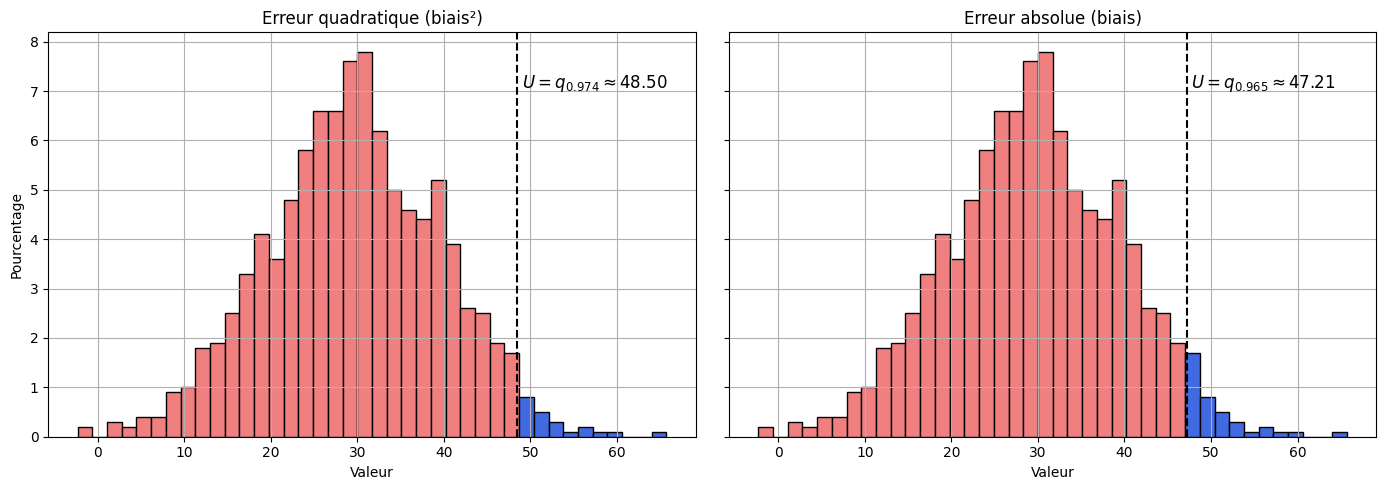

{'U_quadratique': np.float64(48.499811318785696), 'alpha_quadratique': np.float64(0.974), 'U_absolue': np.float64(47.209203734611556), 'alpha_absolue': np.float64(0.965)}


In [5]:
np.random.seed(123)
data = np.random.normal(loc=30, scale=10, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

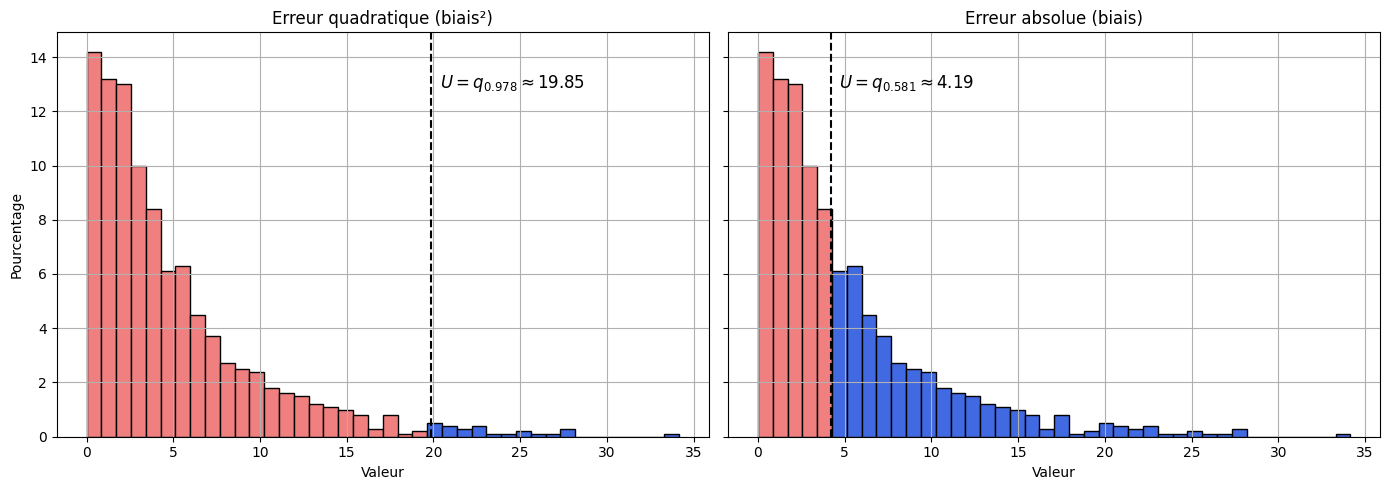

{'U_quadratique': np.float64(19.847674278064268), 'alpha_quadratique': np.float64(0.978), 'U_absolue': np.float64(4.189999999998767), 'alpha_absolue': np.float64(0.581)}


In [3]:
np.random.seed(123)
data = np.random.exponential(scale=5, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

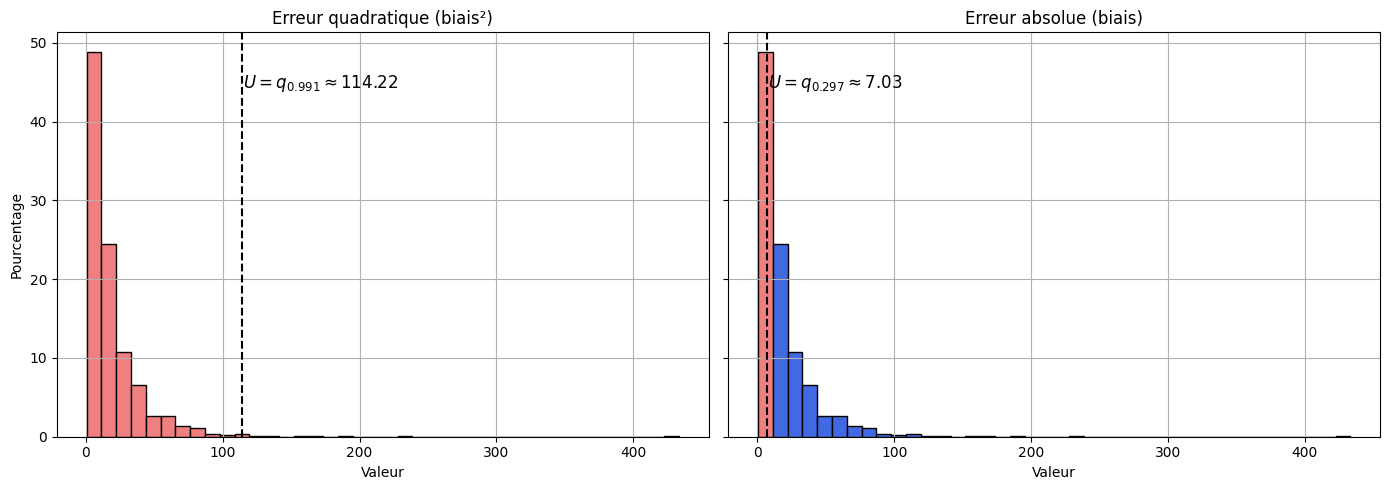

{'U_quadratique': np.float64(114.22193031754573), 'alpha_quadratique': np.float64(0.991), 'U_absolue': np.float64(7.033937544168474), 'alpha_absolue': np.float64(0.297)}


In [68]:
np.random.seed(123)
data = np.random.lognormal(mean=2.5, sigma=1.0, size=1000)
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

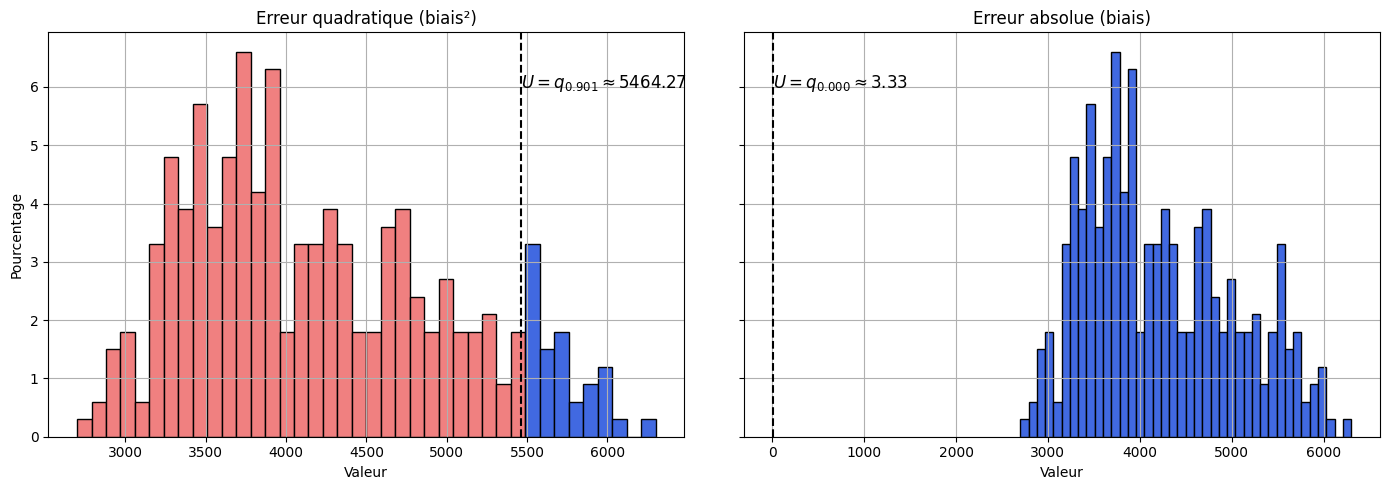

{'U_quadratique': np.float64(5464.2669007903), 'alpha_quadratique': np.float64(0.9009009009009009), 'U_absolue': np.float64(3.3300000000025047), 'alpha_absolue': np.float64(0.0)}


In [69]:
np.random.seed(123)
data = sns.load_dataset("penguins").dropna()["body_mass_g"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

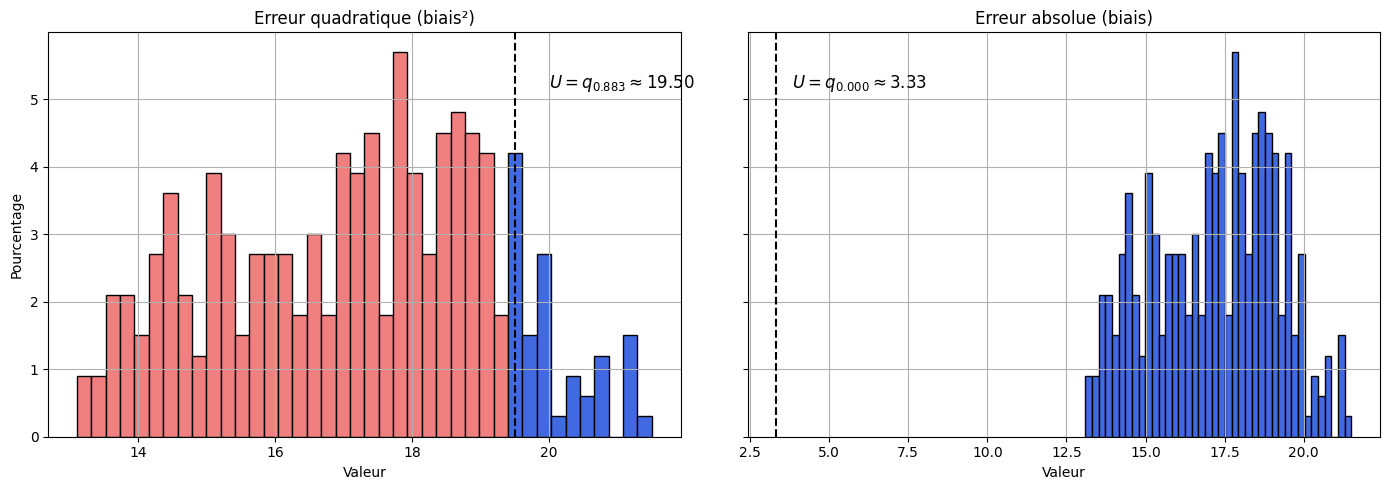

{'U_quadratique': np.float64(19.499997098365437), 'alpha_quadratique': np.float64(0.8828828828828829), 'U_absolue': np.float64(3.3300000000000054), 'alpha_absolue': np.float64(0.0)}


In [60]:
np.random.seed(123)
data = sns.load_dataset("penguins").dropna()["bill_depth_mm"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

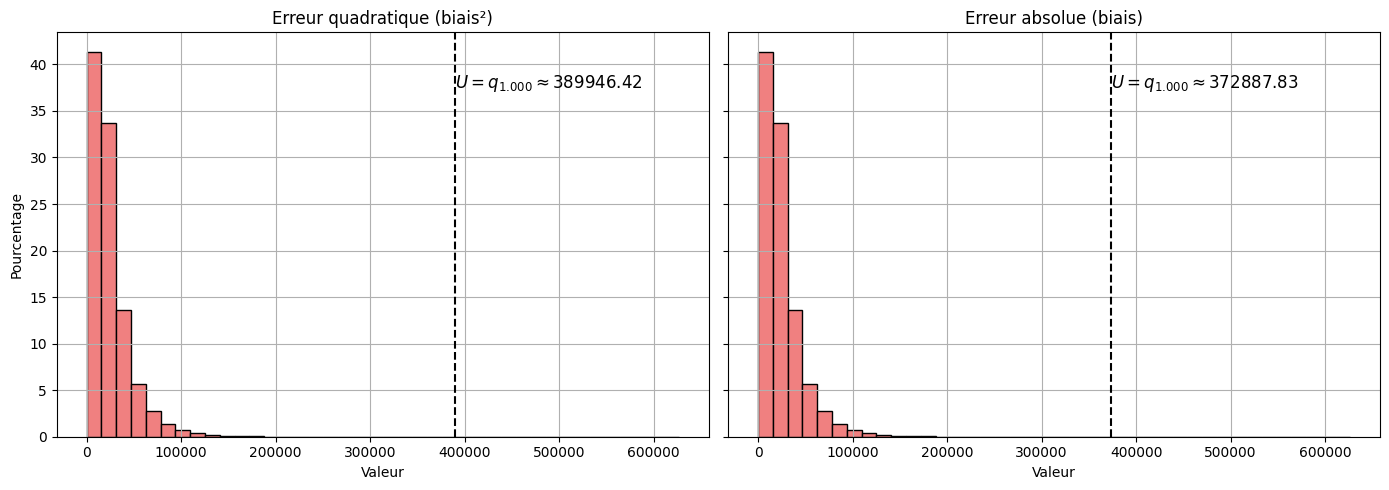

{'U_quadratique': np.float64(389946.41622607474), 'alpha_quadratique': np.float64(0.9999996823952783), 'U_absolue': np.float64(372887.8280517965), 'alpha_absolue': np.float64(0.9999995712336256)}
Le max du Niveau de vie : 626638.0824778209


In [8]:
import polars as pl
import os 

storage_options = {
    "aws_access_key_id": os.environ["AWS_ACCESS_KEY_ID"],
    "aws_secret_access_key": os.environ["AWS_SECRET_ACCESS_KEY"],
    "aws_session_token": os.environ["AWS_SESSION_TOKEN"],
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/METRO/population/population_METRO.parquet"


df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

print("Le max du Niveau de vie :", data.max())


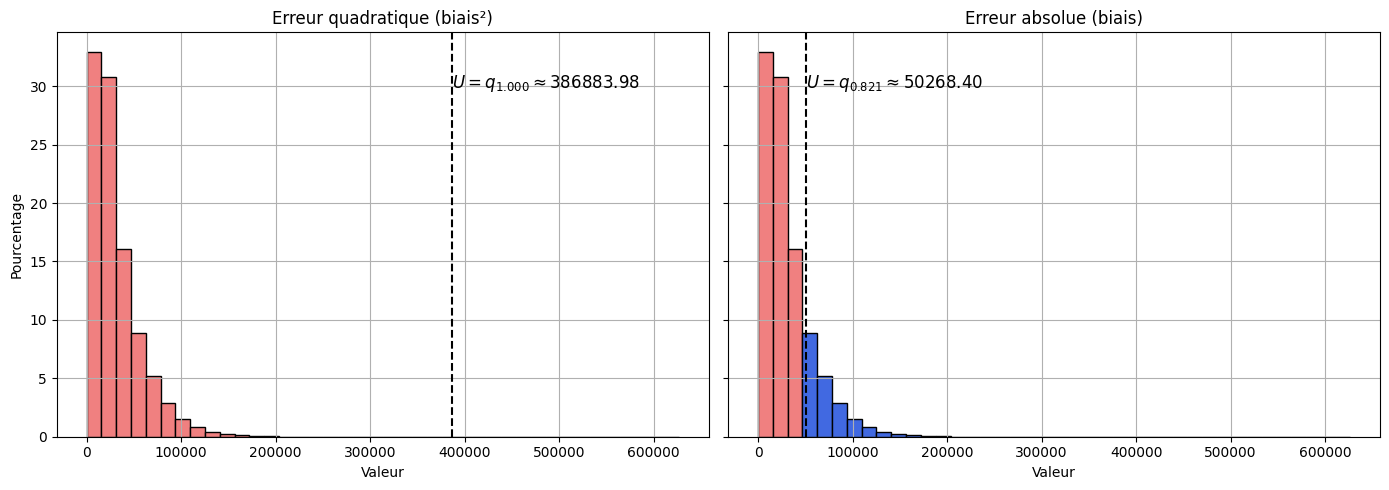

{'U_quadratique': np.float64(386883.98488284694), 'alpha_quadratique': np.float64(0.9999992882494648), 'U_absolue': np.float64(50268.40443819809), 'alpha_absolue': np.float64(0.8211071969972099)}
Le max du Niveau de vie : 626638.0824778209


In [62]:
import polars as pl
import os 

storage_options = {
    "aws_access_key_id": os.environ["AWS_ACCESS_KEY_ID"],
    "aws_secret_access_key": os.environ["AWS_SECRET_ACCESS_KEY"],
    "aws_session_token": os.environ["AWS_SESSION_TOKEN"],
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/METRO/households/households_METRO.parquet"


df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

print("Le max du Niveau de vie :", data.max())

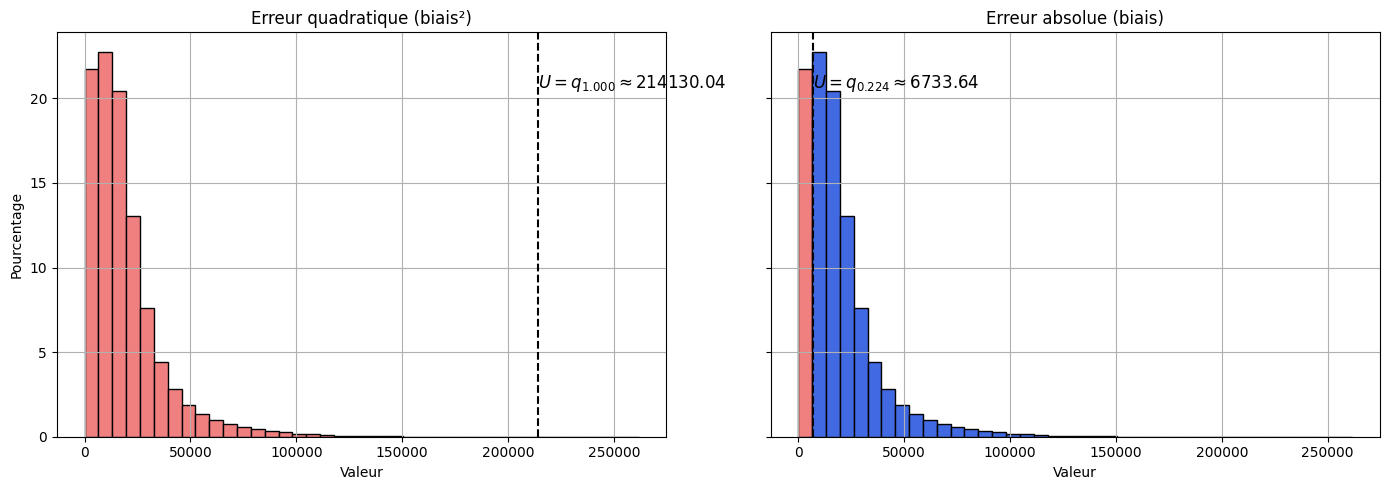

{'U_quadratique': np.float64(214130.0362700548), 'alpha_quadratique': np.float64(0.9999711819548317), 'U_absolue': np.float64(6733.639998921364), 'alpha_absolue': np.float64(0.22379863333302594)}
Le max du Niveau de vie : 261643.51132443073


In [63]:
import polars as pl
import os 

storage_options = {
    "aws_access_key_id": os.environ["AWS_ACCESS_KEY_ID"],
    "aws_secret_access_key": os.environ["AWS_SECRET_ACCESS_KEY"],
    "aws_session_token": os.environ["AWS_SESSION_TOKEN"],
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/974/population/population_974.parquet"


df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

print("Le max du Niveau de vie :", data.max())

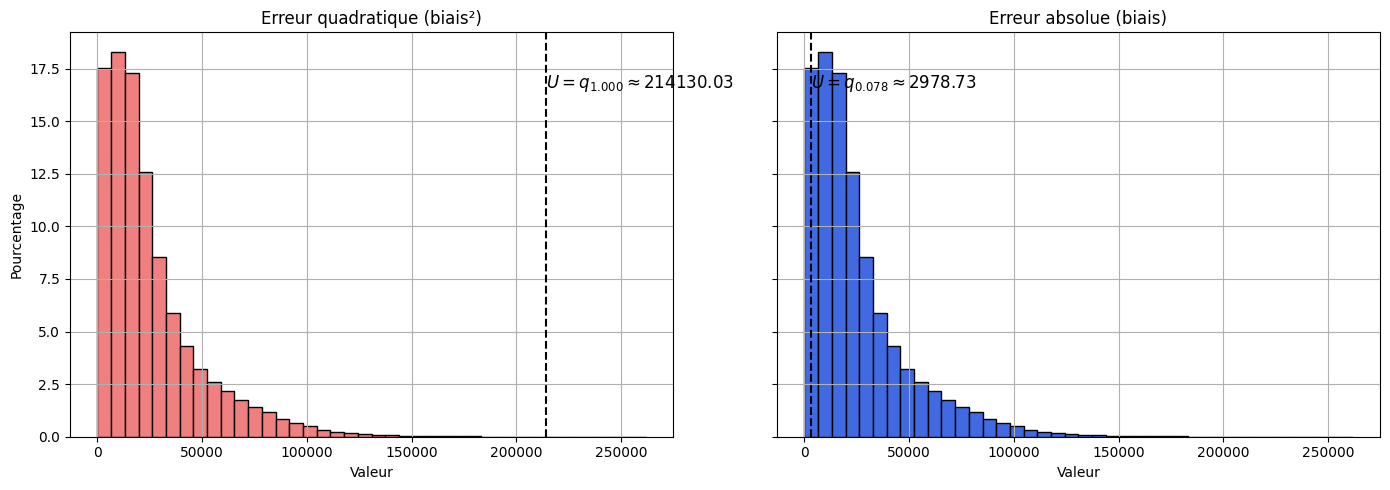

{'U_quadratique': np.float64(214130.0340260915), 'alpha_quadratique': np.float64(0.9999226573690512), 'U_absolue': np.float64(2978.7267498944907), 'alpha_absolue': np.float64(0.07846873965542311)}
Le max du Niveau de vie : 261643.51132443073


In [64]:
import polars as pl
import os 

storage_options = {
    "aws_access_key_id": os.environ["AWS_ACCESS_KEY_ID"],
    "aws_secret_access_key": os.environ["AWS_SECRET_ACCESS_KEY"],
    "aws_session_token": os.environ["AWS_SESSION_TOKEN"],
    "endpoint_url": "https://minio.lab.sspcloud.fr",
}

source = "s3://gferey/diffusion/synthetic-filo/974/households/households_974.parquet"


df = pl.read_parquet(source, storage_options=storage_options)
data = df["NIVEAU_VIE"]
rho = 0.01

res = plot_optimal_truncation(data, rho)
print(res)

print("Le max du Niveau de vie :", data.max())